In [41]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns 
from matplotlib import pyplot as plt

### Load Data

In [8]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
df = iris.frame
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
df.target.unique()

array([0, 1, 2])

In [13]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [9]:
df.shape

(150, 5)

In [14]:
df["target_name"] = df["target"].map({0 : "setosa" , 1: "versicolor" , 2 : 'virginica' })

In [15]:
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
80,5.5,2.4,3.8,1.1,1,versicolor
140,6.7,3.1,5.6,2.4,2,virginica
144,6.7,3.3,5.7,2.5,2,virginica
14,5.8,4.0,1.2,0.2,0,setosa
16,5.4,3.9,1.3,0.4,0,setosa


### Data visuallization

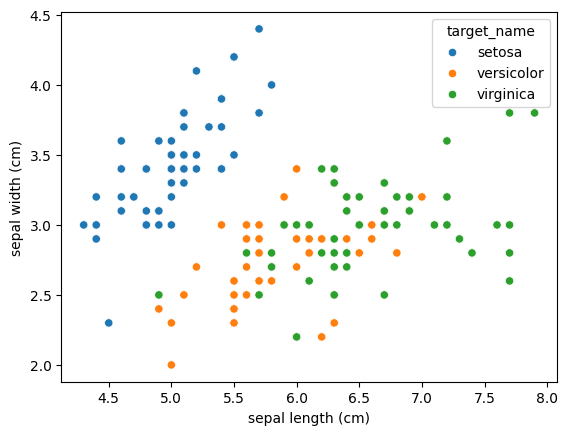

In [28]:
sns.scatterplot(df , x="sepal length (cm)" , y="sepal width (cm)" , hue="target_name")
plt.show()

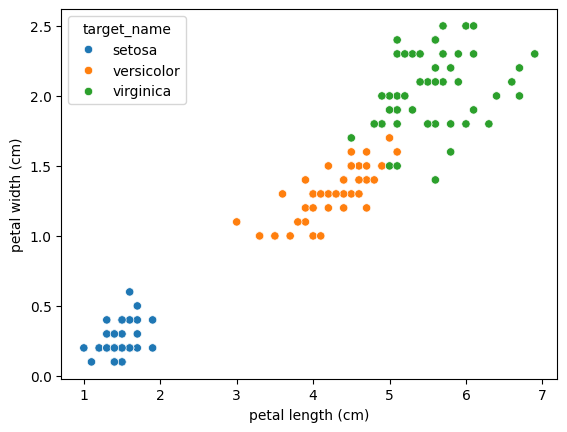

In [29]:
sns.scatterplot(df , x="petal length (cm)" , y="petal width (cm)" , hue="target_name")
plt.show()

### model Training 

In [33]:
#seprate features 
X = df.drop(["target", "target_name"], axis=1)
y = df["target"]


In [51]:
# using train_test_split and fit methd to train a data 
x_train , x_test , y_train , y_test = train_test_split(X , y , test_size=0.3 , random_state=42)
model = LogisticRegression()
model.fit(x_train , y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [52]:
# predict the score using score 
model.score(x_test , y_test)

1.0

In [55]:
### using accuracy to show the accuracy of traing data 
y_predict = model.predict(x_test)
accuracy = accuracy_score(y_predict , y_test)
accuracy 

1.0

### print the precision and recall 

In [60]:
report = classification_report(y_predict , y_test)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### confusion matrix 

In [62]:
cm = confusion_matrix(y_test , y_predict)
print(cm)

[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


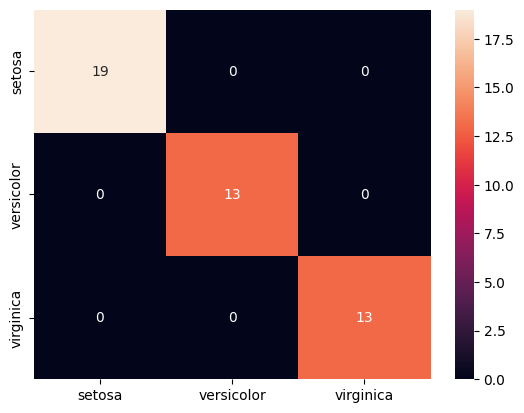

In [70]:
sns.heatmap(cm, xticklabels=iris.target_names , yticklabels=iris.target_names , annot=True )
plt.show()